In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, mean_squared_error, r2_score,
    classification_report, confusion_matrix
)

%matplotlib inline

In [2]:
#Task 1
np.random.seed(42)
n = 500
neighborhoods = ['Downtown', 'Suburbs', 'Rural', 'Uptown', 'Midtown']

df_houses = pd.DataFrame({
    'sqft':         np.random.randint(500, 5000, n).astype(float),
    'bedrooms':     np.random.randint(1, 6, n),
    'bathrooms':    np.random.randint(1, 4, n).astype(float),
    'age':          np.random.randint(1, 50, n),
    'neighborhood': np.random.choice(neighborhoods, n),
})

df_houses['price'] = (
    df_houses['sqft'] * 150
    + df_houses['bedrooms'] * 10000
    + df_houses['bathrooms'] * 8000
    - df_houses['age'] * 500
    + df_houses['neighborhood'].map({'Downtown': 50000, 'Uptown': 40000,
                                     'Midtown': 20000, 'Suburbs': 5000, 'Rural': 0})
    + np.random.normal(0, 15000, n)
)

idx = np.random.choice(n, 20, replace=False)
df_houses.loc[idx[:10], 'sqft']      = np.nan
df_houses.loc[idx[10:], 'bathrooms'] = np.nan

print('Dataset shape:', df_houses.shape)
df_houses.head(10)

Dataset shape: (500, 6)


,sqft,bedrooms,bathrooms,age,neighborhood,price
0,1360.0,1,3.0,28,Suburbs,217226.525304
1,4272.0,1,2.0,15,Midtown,689024.206508
2,3592.0,3,2.0,30,Uptown,607985.777771
3,966.0,5,2.0,37,Uptown,238692.986659
4,4926.0,4,1.0,29,Rural,759087.617333
5,3944.0,1,2.0,22,Suburbs,605038.125495
6,3671.0,4,2.0,4,Uptown,655485.720367
7,3419.0,1,2.0,20,Rural,523257.502719
8,630.0,1,3.0,32,Rural,138404.457769
9,2185.0,1,3.0,36,Midtown,357755.457216


In [3]:
print('Dataset Info')
df_houses.info()
print()
print('Basic Statistics')
df_houses.describe()

Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sqft          490 non-null    float64
 1   bedrooms      500 non-null    int32  
 2   bathrooms     490 non-null    float64
 3   age           500 non-null    int32  
 4   neighborhood  500 non-null    str    
 5   price         500 non-null    float64
dtypes: float64(3), int32(2), str(1)
memory usage: 19.7 KB

Basic Statistics


,sqft,bedrooms,bathrooms,age,price
count,490.000000,500.000000,490.000000,500.000000,500.000000
mean,2814.946939,2.970000,1.983673,24.308000,478187.384064
std,1256.965561,1.452349,0.821328,14.004764,191763.376403
min,504.000000,1.000000,1.000000,1.000000,112602.505608
25%,1685.750000,2.000000,1.000000,12.000000,304185.674907
50%,2939.500000,3.000000,2.000000,24.000000,495954.549456
75%,3838.250000,4.000000,3.000000,36.000000,626838.664325
max,4999.000000,5.000000,3.000000,49.000000,869287.806952


In [4]:
print('Missing Values')
print(df_houses.isnull().sum())

Missing Values
sqft            10
bedrooms         0
bathrooms       10
age              0
neighborhood     0
price            0
dtype: int64


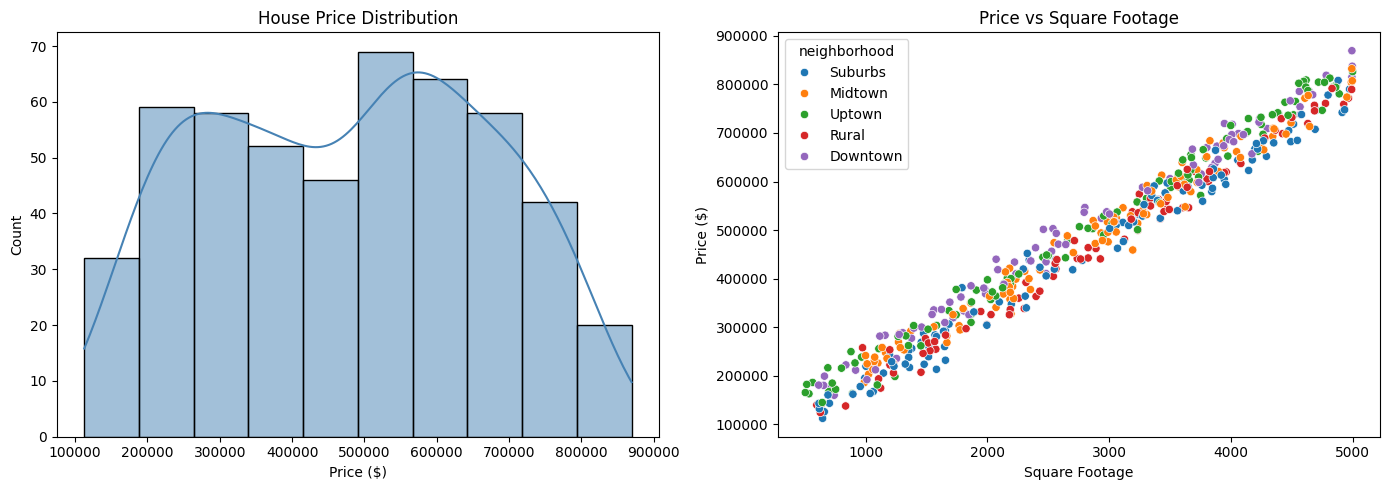

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_houses['price'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('House Price Distribution')
axes[0].set_xlabel('Price ($)')

sns.scatterplot(x='sqft', y='price', data=df_houses, hue='neighborhood', ax=axes[1])
axes[1].set_title('Price vs Square Footage')
axes[1].set_xlabel('Square Footage')
axes[1].set_ylabel('Price ($)')

plt.tight_layout()
plt.show()

In [6]:
df_houses['sqft']      = df_houses['sqft'].fillna(df_houses['sqft'].median())
df_houses['bathrooms'] = df_houses['bathrooms'].fillna(df_houses['bathrooms'].median())

print('Missing values after cleaning:')
print(df_houses.isnull().sum())

Missing values after cleaning:
sqft            0
bedrooms        0
bathrooms       0
age             0
neighborhood    0
price           0
dtype: int64


In [7]:
le = LabelEncoder()
df_houses['neighborhood'] = le.fit_transform(df_houses['neighborhood'])

print('Neighborhood encoding mapping:')
for i, cls in enumerate(le.classes_):
    print(f'  {i} -> {cls}')

Neighborhood encoding mapping:
  0 -> Downtown
  1 -> Midtown
  2 -> Rural
  3 -> Suburbs
  4 -> Uptown


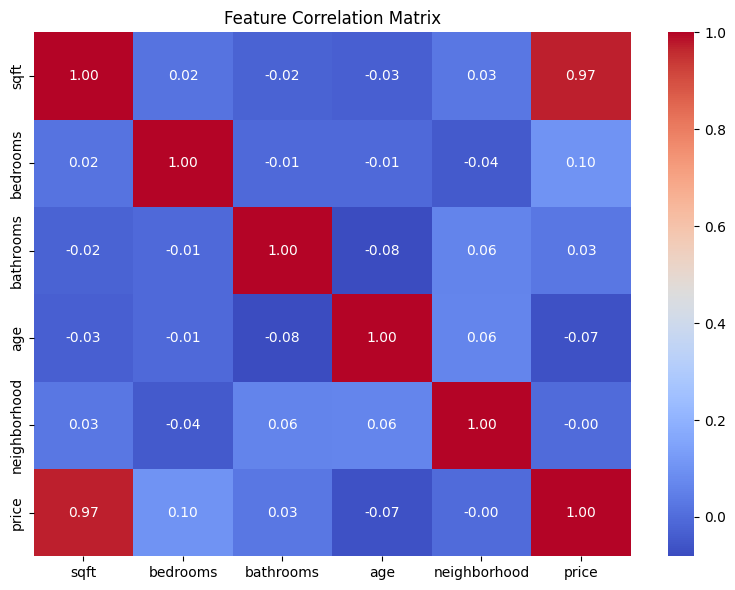


Correlation with price:
price           1.000000
sqft            0.973002
bedrooms        0.101481
bathrooms       0.027946
neighborhood   -0.001960
age            -0.066816
Name: price, dtype: float64


In [8]:
plt.figure(figsize=(8, 6))
corr = df_houses.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

print('\nCorrelation with price:')
print(corr['price'].sort_values(ascending=False))

In [9]:
X1 = df_houses.drop('price', axis=1)
y1 = df_houses['price']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)

print(f'Training samples : {X1_train.shape[0]}')
print(f'Testing  samples : {X1_test.shape[0]}')

Training samples : 400
Testing  samples : 100


In [10]:
LR = LinearRegression()
ModelLR = LR.fit(X1_train, y1_train)

PredictionLR = ModelLR.predict(X1_test)

print('Sample Predictions (first 10):')
for actual, predicted in zip(y1_test[:10], PredictionLR[:10]):
    print(f'  Actual: ${actual:>10,.0f}   |   Predicted: ${predicted:>10,.0f}')

Sample Predictions (first 10):
  Actual: $   537,773   |   Predicted: $   518,848
  Actual: $   420,327   |   Predicted: $   442,187
  Actual: $   611,092   |   Predicted: $   600,596
  Actual: $   399,242   |   Predicted: $   390,117
  Actual: $   224,431   |   Predicted: $   243,704
  Actual: $   736,486   |   Predicted: $   730,988
  Actual: $   298,380   |   Predicted: $   258,386
  Actual: $   670,112   |   Predicted: $   645,924
  Actual: $   256,619   |   Predicted: $   241,414
  Actual: $   703,011   |   Predicted: $   641,560


In [11]:
r2  = r2_score(y1_test, PredictionLR)
rmse = np.sqrt(mean_squared_error(y1_test, PredictionLR))

print('LR Model Evaluation')
print(f'R² Score (Testing Accuracy) : {r2 * 100:.2f}%')
print(f'Root Mean Squared Error     : ${rmse:,.2f}')
print(f'Model Coefficients          : {dict(zip(X1.columns, LR.coef_.round(2)))}')
print(f'Intercept                   : {LR.intercept_:.2f}')

LR Model Evaluation
R² Score (Testing Accuracy) : 96.32%
Root Mean Squared Error     : $35,189.21
Model Coefficients          : {'sqft': np.float64(149.7), 'bedrooms': np.float64(10373.77), 'bathrooms': np.float64(12752.95), 'age': np.float64(-431.5), 'neighborhood': np.float64(-3648.58)}
Intercept                   : 19475.76


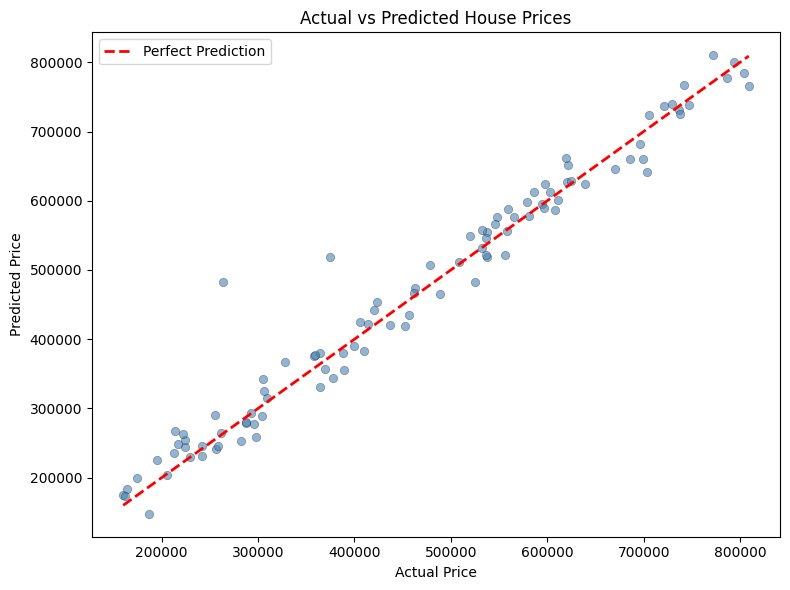

In [12]:

plt.figure(figsize=(8, 6))
plt.scatter(y1_test, PredictionLR, alpha=0.6, color='steelblue', edgecolors='k', linewidths=0.3)
plt.plot([y1_test.min(), y1_test.max()], [y1_test.min(), y1_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
new_house = pd.DataFrame({
    'sqft':         [2000],
    'bedrooms':     [3],
    'bathrooms':    [2],
    'age':          [10],
    'neighborhood': [le.transform(['Downtown'])[0]]  
})

predicted_price = ModelLR.predict(new_house)[0]
print(f'New House Features:')
print(f'  Square Footage : 2000 sqft')
print(f'  Bedrooms       : 3')
print(f'  Bathrooms      : 2')
print(f'  Age            : 10 years')
print(f'  Neighborhood   : Downtown')
print(f'\nPredicted Price  : ${predicted_price:,.0f}')

New House Features:
  Square Footage : 2000 sqft
  Bedrooms       : 3
  Bathrooms      : 2
  Age            : 10 years
  Neighborhood   : Downtown

Predicted Price  : $371,189


In [14]:
#Task2
df_email = pd.read_csv('emails.csv')

print('Dataset shape:', df_email.shape)
df_email.head(5)

FileNotFoundError: [Errno 2] No such file or directory: 'emails.csv'

In [ ]:
print('Class Distribution')
counts = df_email['Prediction'].value_counts()
print(f'Not Spam (0): {counts[0]} emails')
print(f'Spam     (1): {counts[1]} emails')

print(f'\nTotal missing values: {df_email.isnull().sum().sum()}')
print(f'Total duplicates    : {df_email.duplicated().sum()}')

Class Distribution


NameError: name 'df_email' is not defined

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Prediction', data=df_email, palette='Set2', ax=axes[0])
axes[0].set_xticklabels(['Not Spam', 'Spam'])
axes[0].set_title('Email Class Count')
for container in axes[0].containers:
    axes[0].bar_label(container, color='black', size=12)

axes[1].pie(counts.values, labels=['Not Spam', 'Spam'],
            autopct='%1.1f%%', shadow=True, explode=[0, 0.1],
            colors=['#66b3ff', '#ff9999'])
axes[1].set_title('Spam Distribution')

plt.tight_layout()
plt.show()

In [ ]:

word_cols = [c for c in df_email.columns if c not in ['Email No.', 'Prediction']]

X2 = df_email[word_cols]   
y2 = df_email['Prediction']

print(f'Feature matrix shape : {X2.shape}')
print(f'Target vector shape  : {y2.shape}')

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

sc2 = StandardScaler()
X2_train_sc = sc2.fit_transform(X2_train)
X2_test_sc  = sc2.transform(X2_test)

print(f'Training samples : {X2_train.shape[0]}')
print(f'Testing  samples : {X2_test.shape[0]}')

In [ ]:
svm_email = SVC(kernel='rbf', C=1, gamma='scale', random_state=42)
svm_email.fit(X2_train_sc, y2_train)

print('SVM model trained successfully.')
print(f'Kernel : {svm_email.kernel}')
print(f'C      : {svm_email.C}')

In [ ]:
y2_pred = svm_email.predict(X2_test_sc)

print('SVM Email Classifier Evaluation')
print(f'Accuracy: {accuracy_score(y2_test, y2_pred) * 100:.2f}%')
print()
print('Classification Report:')
print(classification_report(y2_test, y2_pred, target_names=['Not Spam', 'Spam']))

In [ ]:

cm = confusion_matrix(y2_test, y2_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.title('Confusion Matrix — SVM Email Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:

new_emails_raw = pd.DataFrame(np.zeros((3, len(word_cols))), columns=word_cols)

new_emails_raw.iloc[0, :5]   = [15, 10, 5, 20, 8]
new_emails_raw.iloc[1, :5]   = [1, 0, 0, 1, 0]
new_emails_raw.iloc[2, :5]   = [8, 5, 3, 9, 4]

new_emails_sc = sc2.transform(new_emails_raw)
new_preds = svm_email.predict(new_emails_sc)

label_map = {0: 'Not Spam', 1: 'Spam'}
print('New Email Classification Results:')
for i, pred in enumerate(new_preds):
    print(f'  Email {i+1}: {label_map[pred]}')

In [ ]:
#Task3
np.random.seed(0)
n3 = 600

df_cust = pd.DataFrame({
    'spending':      np.random.randint(100, 5000, n3).astype(float),
    'age':           np.random.randint(18, 70,   n3).astype(float),
    'visits':        np.random.randint(1,  30,   n3),
    'purchase_freq': np.random.randint(1,  20,   n3),
})

df_cust['high_value'] = ((df_cust['spending'] > 2500) | (df_cust['visits'] > 20)).astype(int)

df_cust.loc[np.random.choice(n3, 10, replace=False), 'spending'] = np.nan
df_cust.loc[np.random.choice(n3, 5,  replace=False), 'age']      = 200.0  

print('Dataset shape:', df_cust.shape)
df_cust.head(10)

In [ ]:
print('Missing Values')
print(df_cust.isnull().sum())
print()
print('Class Distribution')
print(df_cust['high_value'].value_counts())
print()
df_cust.describe()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cnt = df_cust['high_value'].value_counts()
axes[0].pie(cnt.values, labels=['Low Value', 'High Value'],
            autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], shadow=True)
axes[0].set_title('Customer Class Distribution')

sns.histplot(data=df_cust, x='spending', hue=df_cust['high_value'].map({0:'Low',1:'High'}),
             kde=True, ax=axes[1])
axes[1].set_title('Spending by Customer Class')

sns.scatterplot(x='visits', y='spending', hue=df_cust['high_value'].map({0:'Low',1:'High'}),
                data=df_cust, ax=axes[2], palette='Set1', alpha=0.7)
axes[2].set_title('Visits vs Spending')
axes[2].axhline(2500, color='gray', linestyle='--', linewidth=1, label='Threshold')
axes[2].axvline(20,   color='gray', linestyle=':',  linewidth=1)

plt.tight_layout()
plt.show()

In [ ]:

df_cust['spending'] = df_cust['spending'].fillna(df_cust['spending'].median())

df_cust['age'] = df_cust['age'].clip(upper=100)

print('After cleaning:')
print('Missing values:', df_cust.isnull().sum().to_dict())
print('Age max:', df_cust['age'].max())

In [ ]:
X3 = df_cust.drop('high_value', axis=1)
y3 = df_cust['high_value']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

sc3 = StandardScaler()
X3_train_sc = sc3.fit_transform(X3_train)
X3_test_sc  = sc3.transform(X3_test)

print(f'Training samples : {X3_train.shape[0]}')
print(f'Testing  samples : {X3_test.shape[0]}')

In [ ]:

svm_cust = SVC(kernel='rbf', C=1, gamma='scale')
svm_cust.fit(X3_train_sc, y3_train)

y3_pred_svm = svm_cust.predict(X3_test_sc)

print('SVM Customer Classifier')
print(f'Accuracy: {accuracy_score(y3_test, y3_pred_svm) * 100:.2f}%')
print()
print(classification_report(y3_test, y3_pred_svm, target_names=['Low Value', 'High Value']))

In [ ]:
DT = DecisionTreeClassifier(max_depth=4, random_state=42)
ModelDT = DT.fit(X3_train, y3_train)

print('DT Training Accuracy')
tracDT = DT.score(X3_train, y3_train)
print(f'Training Accuracy: {tracDT * 100:.2f}%')

PredictionDT = DT.predict(X3_test)
print('DT Testing Accuracy')
teacDT = accuracy_score(y3_test, PredictionDT)
print(f'Testing Accuracy : {teacDT * 100:.2f}%')
print()
print(classification_report(y3_test, PredictionDT, target_names=['Low Value', 'High Value']))

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(
    DT,
    feature_names=X3.columns.tolist(),
    class_names=['Low Value', 'High Value'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title('Decision Tree', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_svm = confusion_matrix(y3_test, y3_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'], ax=axes[0])
axes[0].set_title(f'SVM Confusion Matrix\nAccuracy: {accuracy_score(y3_test, y3_pred_svm)*100:.1f}%')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

cm_dt = confusion_matrix(y3_test, PredictionDT)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low', 'High'], yticklabels=['Low', 'High'], ax=axes[1])
axes[1].set_title(f'Decision Tree Confusion Matrix\nAccuracy: {accuracy_score(y3_test, PredictionDT)*100:.1f}%')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [ ]:
importances = pd.Series(DT.feature_importances_, index=X3.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Decision Tree')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Feature Importances:')
for feat, imp in importances.items():
    print(f'  {feat:<15}: {imp:.4f}')